## Task 1: KNN on IRIS Dataset

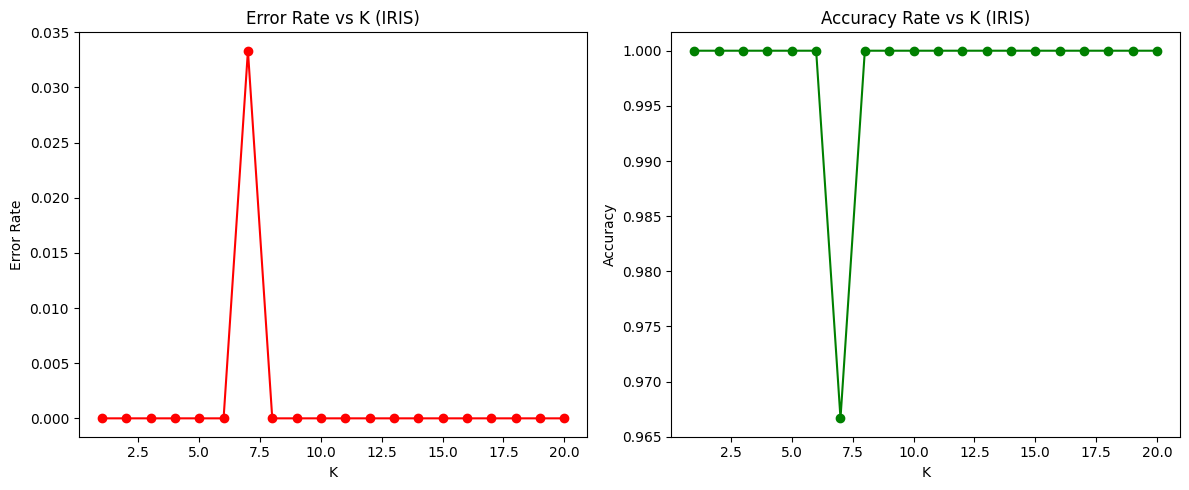

Best K for IRIS: 1

Accuracy Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



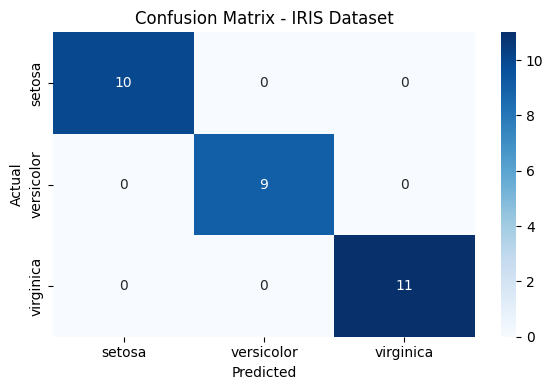

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# Load IRIS dataset (use iris.csv if available)
# df_iris = pd.read_csv('iris.csv')
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Find best K using error rate and accuracy rate
error_rate = []
accuracy_rate = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    error_rate.append(np.mean(pred != y_test))
    accuracy_rate.append(accuracy_score(y_test, pred))

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1,21), error_rate, marker='o', color='red')
plt.title('Error Rate vs K (IRIS)')
plt.xlabel('K'); plt.ylabel('Error Rate')

plt.subplot(1, 2, 2)
plt.plot(range(1,21), accuracy_rate, marker='o', color='green')
plt.title('Accuracy Rate vs K (IRIS)')
plt.xlabel('K'); plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

best_k = accuracy_rate.index(max(accuracy_rate)) + 1
print(f'Best K for IRIS: {best_k}')

# Train with best K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f'\nAccuracy Score: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix - IRIS Dataset')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Task 2: KNN on Diabetes Dataset (with Feature Scaling)

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Shape: (768, 9)
Best K for Diabetes: 18

Accuracy Score: 0.7597

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.89      0.83        99
           1       0.72      0.53      0.61        55

    accuracy                           0.76       1

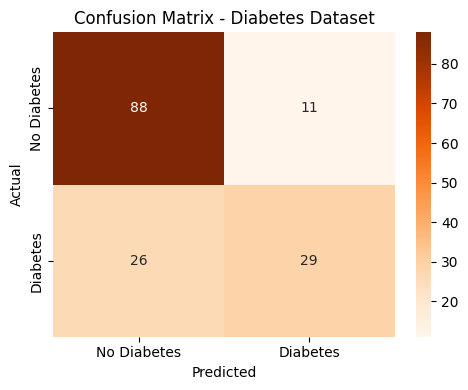

In [6]:
# Load dataset
df_diabetes = pd.read_csv('diabetes.csv')
print(df_diabetes.head())
print(f'Shape: {df_diabetes.shape}')

X = df_diabetes.drop('Outcome', axis=1)
y = df_diabetes['Outcome']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Find best K
error_rate = []
accuracy_rate = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred != y_test))
    accuracy_rate.append(accuracy_score(y_test, pred))

best_k = accuracy_rate.index(max(accuracy_rate)) + 1
print(f'Best K for Diabetes: {best_k}')

# Train with best K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print(f'\nAccuracy Score: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Diabetes','Diabetes'],
            yticklabels=['No Diabetes','Diabetes'])
plt.title('Confusion Matrix - Diabetes Dataset')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Task 3: KNN on Heart Dataset

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
Shape: (303, 14)


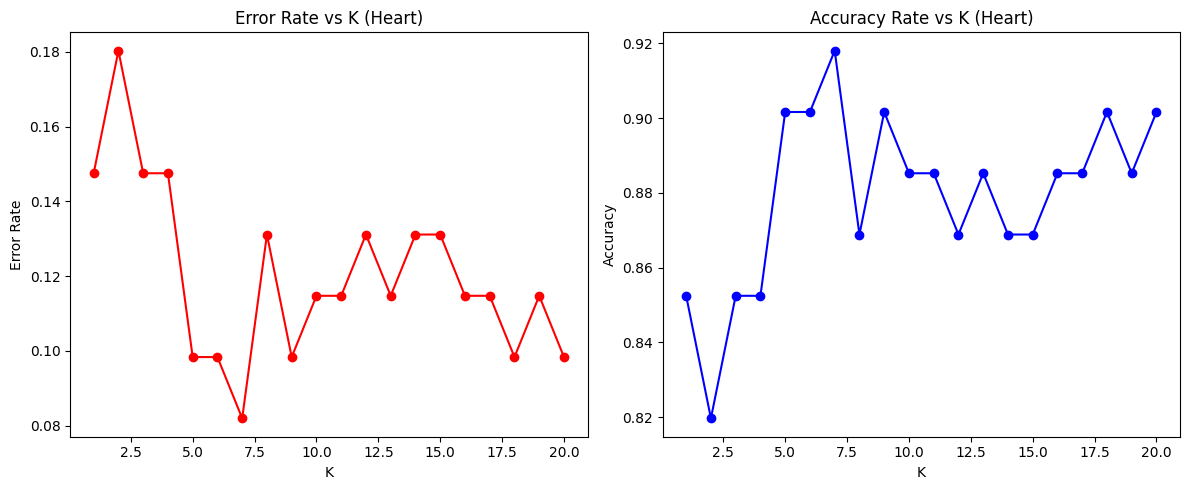

Best K for Heart Dataset: 7

Accuracy Score: 0.9180


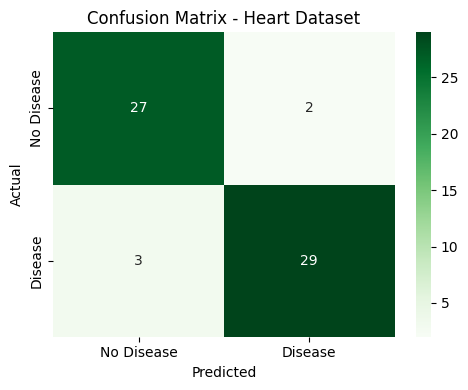


Classification Report:
              precision    recall  f1-score   support

  No Disease       0.90      0.93      0.92        29
     Disease       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



In [3]:
# Load dataset
df_heart = pd.read_csv('heart.csv')
print(df_heart.head())
print(f'Shape: {df_heart.shape}')

X = df_heart.drop('target', axis=1)
y = df_heart['target']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Find best K
error_rate = []
accuracy_rate = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred != y_test))
    accuracy_rate.append(accuracy_score(y_test, pred))

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1,21), error_rate, marker='o', color='red')
plt.title('Error Rate vs K (Heart)')
plt.xlabel('K'); plt.ylabel('Error Rate')

plt.subplot(1, 2, 2)
plt.plot(range(1,21), accuracy_rate, marker='o', color='blue')
plt.title('Accuracy Rate vs K (Heart)')
plt.xlabel('K'); plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

best_k = accuracy_rate.index(max(accuracy_rate)) + 1
print(f'Best K for Heart Dataset: {best_k}')

# Train with best K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print(f'\nAccuracy Score: {accuracy_score(y_test, y_pred):.4f}')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])
plt.title('Confusion Matrix - Heart Dataset')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Classification Report
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Disease','Disease']))